[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jen1995/jen1995.github.io/blob/main/notebooks/transformer_blocks.ipynb)

This notebook accompanies **Part 2** of the post [Transformers from Scratch](https://jen1995.github.io/posts/transformers/): every building block of the Transformer — intuition, PyTorch code, a pure-numpy reference and a cross-check. Runs on a CPU in under a minute.

# Transformers from Scratch. Part 2 — The building blocks, with code

In Part 1 we looked at the architecture from a bird's-eye view. Now let us come down to earth and assemble every block by hand. The format for every building block is the same: intuition → formula → PyTorch code → a reference implementation in pure numpy for cross-checking → an honest complexity count for that block.

Why a numpy reference? PyTorch modules are convenient, but they hide the details behind library calls. Implementing the same computations "by hand" in numpy leaves no room for misunderstanding: if two independent pieces of code produce the same numbers, we really do understand what happens inside. We will check every block via `np.allclose`.

Notation for the whole series: $n$ — sequence length, $d$ — model dimension, $h$ — number of attention heads, $d_{ff}$ — inner dimension of the FFN, $|V|$ — vocabulary size.

One thing we leave out of scope: tokenization. We assume the text has already been turned into a sequence of integer token ids — how exactly text is cut into tokens (usually with the BPE algorithm) is well described, for example, in [Lena Voita's course chapter](https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html) and in [Sennrich et al., 2016](https://arxiv.org/abs/1508.07909).

Set up the environment:

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

n, d, h, d_ff, vocab_size = 6, 16, 4, 64, 100  # toy sizes for the checks

## Tokens → embeddings

**Intuition.** The model cannot work with token ids directly — it needs vectors. The embedding table is simply a matrix $E$ of size $|V| \times d$: one row per vocabulary token. "Turning a token into a vector" means taking the row of the matrix with that token's id.

**Formula.** For a sequence of ids $t_1, \dots, t_n$:

$$
X = (E_{t_1}, \dots, E_{t_n}) \in \mathbb{R}^{n \times d}.
$$

**Code.** In PyTorch this is `nn.Embedding`, in numpy — plain indexing:

In [2]:
emb = nn.Embedding(vocab_size, d)
token_ids = torch.randint(0, vocab_size, (n,))

x_torch = emb(token_ids)                            # (n, d)

E = emb.weight.detach().numpy()                     # (|V|, d)
x_np = E[token_ids.numpy()]                         # the same operation by hand

assert np.allclose(x_torch.detach().numpy(), x_np)
print("embeddings: ok", x_torch.shape)

embeddings: ok torch.Size([6, 16])


**Complexity.** No multiplications: $n$ lookups into the table's rows, an $n \times d$ matrix as output — that is, $O(n \cdot d)$ in the size of the result. The main cost of embeddings is not compute but parameters: $|V| \cdot d$ numbers, a noticeable share of the model when the vocabulary is large.

A small detail from the original paper: before entering the model, the embeddings are multiplied by $\sqrt{d}$ — so that their scale is not drowned out by the positional encoding we are about to add to them. We will account for this when assembling the full model in Part 3.

## Positional encoding

**Intuition.** In Part 1 we established: self-attention does not see token order — a weighted sum does not care in what order its summands come. For language this is a catastrophe ("the cat ate the mouse" and "the mouse ate the cat" are different events), so position information must be put back into the model explicitly. The original paper's solution: add to each token's embedding a vector that depends only on the token's *position* in the sequence.

**Formula.** The positional vector for position $pos$ is composed of sines and cosines of different frequencies:

$$
PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right),
$$

where $i$ runs over pairs of coordinates. Each coordinate pair is its own "clock hand": the first pairs rotate fast (change from token to token), the last ones — very slowly. A set of $d/2$ such hands encodes the position unambiguously, just as a clock with a second, minute and hour hand encodes the time.

**Code.**

In [3]:
def positional_encoding(n, d):
    pos = torch.arange(n).unsqueeze(1)               # (n, 1)
    i = torch.arange(0, d, 2)                        # (d/2,)
    angles = pos / 10000 ** (i / d)                  # (n, d/2)
    pe = torch.zeros(n, d)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe

def positional_encoding_np(n, d):
    pos = np.arange(n)[:, None]
    i = np.arange(0, d, 2)
    angles = pos / 10000 ** (i / d)
    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(angles)
    pe[:, 1::2] = np.cos(angles)
    return pe

pe = positional_encoding(n, d)
assert np.allclose(pe.numpy(), positional_encoding_np(n, d), atol=1e-6)
print("positional encoding: ok", pe.shape)

positional encoding: ok torch.Size([6, 16])


It is worth seeing this matrix with your own eyes once:

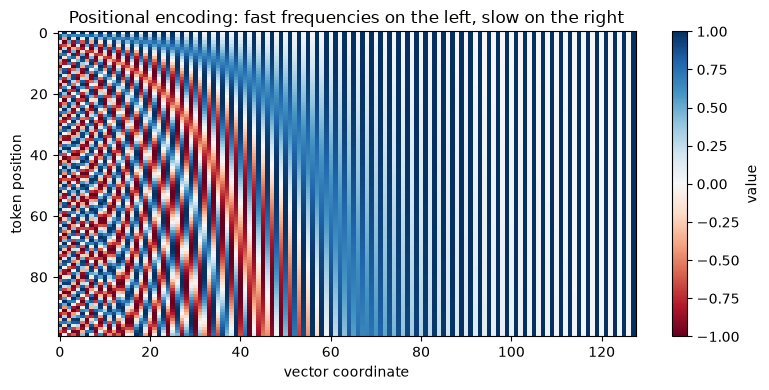

In [4]:
import matplotlib.pyplot as plt

pe_big = positional_encoding(100, 128)
plt.figure(figsize=(8, 4))
plt.imshow(pe_big.numpy(), aspect="auto", cmap="RdBu")
plt.xlabel("vector coordinate")
plt.ylabel("token position")
plt.colorbar(label="value")
plt.title("Positional encoding: fast frequencies on the left, slow on the right")
plt.tight_layout()
plt.show()

Each column is one coordinate of the vector, each row is a position in the sequence. The left coordinates oscillate fast and distinguish neighboring tokens; the right ones change slowly and encode the "coarse scale" of the position.

**Complexity.** Adding a positional vector to each of the $n$ vectors of size $d$ — $O(n \cdot d)$. The positional vectors themselves are not trained and are computed once.

## Scaled dot-product attention

The central block of the whole architecture.

**Intuition.** In Part 0, attention worked like this: there is a query (the decoder state), there is a set of candidates (the encoder states); we compute each candidate's relevance to the query and take a weighted sum. Let us generalize this into three roles a vector can play:

- **query** $q$ — "what I am looking for";
- **key** $k$ — "by what feature I can be found";
- **value** $v$ — "what I will hand over if I am chosen".

The analogy is a library search: the query is compared against the catalog cards (keys), and based on the comparison a mixture of books (values) is returned. Importantly, the "card" and the "book" are different objects: a token can be *found* by one feature and *hand over* entirely different information.

In the diagram, each vector receives its three roles through three matrices $W^Q$, $W^K$, $W^V$ — these learnable projections will appear a bit below, in multi-head attention; the attention operation itself, which we are about to write, takes ready-made $Q$, $K$, $V$.

**Formula.** We stack the queries, keys and values into matrices $Q$ ($n_q \times d_k$), $K$, $V$ ($n_k \times d_k$ and $n_k \times d_v$):

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

Here $QK^\top$ is the score table "every query against every key", familiar from Parts 0–1; the softmax turns each row into a distribution of weights, and the multiplication by $V$ takes weighted sums of the values.

> 💡 **Why $\sqrt{d_k}$, and not $d_k$ or nothing?** The dot product of two random vectors with $d_k$ independent components of zero mean and unit variance has variance $d_k$ ([a careful derivation via the variance of a product of independent variables](https://ai.stackexchange.com/questions/21237/why-does-this-multiplication-of-q-and-k-have-a-variance-of-d-k-in-scaled)) — that is, the typical spread of the scores grows as $\sqrt{d_k}$. One might think the softmax cares not about scale but only about the relative magnitudes of the scores. Let us write out the formula and check: for a score vector $s = (s_1, \dots, s_n)$, the weight of the $i$-th element is
>
> $$p_i = \mathrm{softmax}(s)_i = \frac{e^{s_i}}{\sum_{k=1}^{n} e^{s_k}}.$$
>
> For a *shift* the intuition is correct: add a constant $c$ to all scores — the numerator and every term of the denominator get multiplied by $e^c$, the common factor cancels, the weights do not change. But *multiplying* the scores by a constant does not cancel: it stretches the differences between scores, which is what the softmax genuinely depends on — dividing $p_i$ by $p_j$, we see $p_i / p_j = e^{s_i - s_j}$. Variance $d_k$ means the typical difference between two scores is of order $\sqrt{d_k}$ in absolute value; at $d_k = 512$ that is tens, and already a logit difference of 20 gives a weight ratio of $e^{20} \approx 5 \cdot 10^8$. The sign of the difference does not matter. To see this, divide the numerator and denominator of the largest score's weight $s_{\max}$ by $e^{s_{\max}}$:
>
> $$p_{\max} = \frac{e^{s_{\max}}}{\sum_{k} e^{s_k}} = \frac{1}{1 + \sum_{k \neq \max} e^{s_k - s_{\max}}}.$$
>
> All the exponents $s_k - s_{\max}$ are negative, and if they are on the order of tens in absolute value, every term in the denominator is $\sim e^{-20} \approx 2 \cdot 10^{-9}$ — that is, $p_{\max} \approx 1$: the largest score takes almost all the weight. And there always is a largest one. That is the problem: at the start the weights are random, so attention "locks onto" a *random* token, and the gradients through the rest are practically zero — training can hardly fix an unlucky choice. Dividing by $\sqrt{d_k}$ returns the differences to a scale of order one. And why not divide by $d_k$? Then typical differences shrink to $1/\sqrt{d_k}$. The exponential is no longer scary on small arguments — it is linear there, $e^x \approx 1 + x$ — so the weight ratios are $p_i/p_j \approx 1 \pm 1/\sqrt{d_k}$: at $d_k = 512$ all weights are almost equal, differing by mere percents. The softmax becomes almost uniform, and attention does not choose — it just averages all the values. Note that this failure is milder than the previous one: the gradients here are alive, but the model would have to learn projections with larger norms, pulling the differences back to a scale of one against the imposed division. Dividing by $\sqrt{d_k}$ is the golden mean: differences of order 1, a softmax that is selective but not locked, and trainable in both directions. Let us check the variance experimentally:
>
> ```python
> d_ks = 2 ** np.arange(2, 13)                     # 4 ... 4096
> var_raw, var_scaled = [], []
> for d_k in d_ks:
>     q = np.random.randn(2000, d_k)
>     k = np.random.randn(2000, d_k)
>     scores = (q * k).sum(axis=1)
>     var_raw.append(scores.var())
>     var_scaled.append((scores / np.sqrt(d_k)).var())
>
> plt.figure(figsize=(7, 3.5))
> plt.loglog(d_ks, d_ks, "--", color="gray", label="theory: $\\mathrm{var} = d_k$")
> plt.loglog(d_ks, var_raw, "o-", label="var($q \\cdot k$)")
> plt.loglog(d_ks, var_scaled, "s-", label="var($q \\cdot k \\,/\\, \\sqrt{d_k}$)")
> plt.xlabel("$d_k$")
> plt.ylabel("score variance")
> plt.grid(alpha=0.3)
> plt.legend()
> plt.tight_layout()
> plt.show()
> ```
>
> The variance of the "raw" scores falls exactly on the line $\mathrm{var} = d_k$; the scaled ones stay around 1 at any dimension.

**Code.** The operation itself is four lines:

In [5]:
def scaled_dot_product_attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / q.shape[-1] ** 0.5   # (..., n_q, n_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)                     # (..., n_q, n_k)
    return weights @ v, weights

**Numpy reference.** We write the softmax ourselves (subtracting the maximum for numerical stability):

In [6]:
def softmax_np(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention_np(q, k, v, mask=None):
    scores = q @ np.swapaxes(k, -2, -1) / np.sqrt(q.shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax_np(scores)
    return weights @ v, weights

q, k, v = torch.randn(n, d), torch.randn(n, d), torch.randn(n, d)
out_torch, w_torch = scaled_dot_product_attention(q, k, v)
out_np, w_np = attention_np(q.numpy(), k.numpy(), v.numpy())

assert np.allclose(out_torch.numpy(), out_np, atol=1e-6)
assert np.allclose(w_torch.numpy(), w_np, atol=1e-6)
print("scaled dot-product attention: ok", out_torch.shape)

scaled dot-product attention: ok torch.Size([6, 16])


**Complexity** (with $n_q = n_k = n$, $d_k = d_v = d$):

- $QK^\top$: multiplying $(n \times d)$ by $(d \times n)$ — $O(n^2 \cdot d)$;
- softmax: $n$ elements in each of $n$ rows — $O(n^2)$;
- the weighted sum $\mathrm{weights} \cdot V$: $(n \times n)$ by $(n \times d)$ — $O(n^2 \cdot d)$.

Total $O(n^2 \cdot d)$ — that very quadraticity in sequence length from Part 1. Note: this block has *zero* parameters — all the learnable weights appear one level up, in multi-head attention.

## Multi-head attention

**Intuition.** One attention — one "view" of the sequence: one weight table per pair of tokens. But tokens are related in several ways at once: syntactically, semantically, by coreference ("he" → "the cat"). The idea of multi-head: run $h$ small attentions in parallel, each in its own subspace of dimension $d/h$ — and let each head learn its own type of relations.

**Formula.** The input $X$ ($n \times d$) first passes through three learnable linear projections:

$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V, \qquad W^Q, W^K, W^V \in \mathbb{R}^{d \times d}.
$$

Then $Q, K, V$ are *sliced* along the coordinates into $h$ heads of size $n \times d/h$; each head computes ordinary scaled dot-product attention (with the scale $\sqrt{d/h}$ — the head's dimension!), the results are glued back into $n \times d$ and pass through the output projection $W^O \in \mathbb{R}^{d \times d}$:

$$
\mathrm{head}_i = \mathrm{Attention}(Q_i, K_i, V_i), \qquad
\mathrm{MultiHead}(X) = \mathrm{Concat}(\mathrm{head}_1, \dots, \mathrm{head}_h)\,W^O.
$$

And here, by the way, is the answer promised in Part 1 to why we need three different projections: they are what creates the query/key/value roles — without them a token would be forced to "search" and "be found" with one and the same vector.

> 💡 **Why do we divide by $\sqrt{d/h}$ in the softmax, and not by $\sqrt{d}$?** Because the dot products are computed *inside a head*, between vectors of dimension $d/h$ — so the score variance also grows as $d/h$, and that is what we must normalize by. The general principle: divide by the square root of the dimension of the vectors actually being multiplied.

**Code.**

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.d, self.h, self.d_head = d, h, d // h
        self.w_q = nn.Linear(d, d, bias=False)
        self.w_k = nn.Linear(d, d, bias=False)
        self.w_v = nn.Linear(d, d, bias=False)
        self.w_o = nn.Linear(d, d, bias=False)

    def split_heads(self, x):          # (n, d) -> (h, n, d/h)
        n = x.shape[0]
        return x.view(n, self.h, self.d_head).transpose(0, 1)

    def forward(self, x_q, x_k, x_v, mask=None):
        q = self.split_heads(self.w_q(x_q))
        k = self.split_heads(self.w_k(x_k))
        v = self.split_heads(self.w_v(x_v))
        out, weights = scaled_dot_product_attention(q, k, v, mask)
        n = out.shape[1]
        concat = out.transpose(0, 1).reshape(n, self.d)   # glue the heads
        return self.w_o(concat), weights

For self-attention all three inputs are the same sequence: `mha(x, x, x)`. For the cross-attention of Part 1, the queries will come from the decoder, and the keys and values from the encoder: `mha(dec, enc, enc)` — the code is one and the same.

> 💡 **Slicing into heads is free.** `view` and `transpose` in PyTorch (like `reshape` in numpy) do not copy or move numbers — they only change the tensor's *metadata*: shapes and memory strides. "Sliced into $h$ heads and glued back" sounds like work, but in fact it is a reinterpretation of the same memory.

**Numpy reference.** We take the weights from the PyTorch module and repeat all the steps by hand (`nn.Linear` stores its matrix transposed, hence the `.T`):

In [8]:
def multi_head_attention_np(x, w_q, w_k, w_v, w_o, h):
    n, d = x.shape
    d_head = d // h

    def split(m):                       # (n, d) -> (h, n, d/h)
        return m.reshape(n, h, d_head).transpose(1, 0, 2)

    q, k, v = split(x @ w_q), split(x @ w_k), split(x @ w_v)
    out, _ = attention_np(q, k, v)
    concat = out.transpose(1, 0, 2).reshape(n, d)
    return concat @ w_o

mha = MultiHeadAttention(d, h)
x = torch.randn(n, d)
out_torch, _ = mha(x, x, x)

weights_np = [m.weight.detach().numpy().T for m in (mha.w_q, mha.w_k, mha.w_v, mha.w_o)]
out_np = multi_head_attention_np(x.numpy(), *weights_np, h)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-6)
print("multi-head attention: ok", out_torch.shape)

multi-head attention: ok torch.Size([6, 16])


**Complexity, line by line.** Let us walk down the forward pass:

| Step | Operation | Complexity |
|---|---|---|
| Projections $XW^Q, XW^K, XW^V$ | $(n \times d) \cdot (d \times d)$, three times | $O(n \cdot d^2)$ |
| Slicing into heads | metadata | $O(1)$* |
| $Q_i K_i^\top$ per head | $(n \times d/h) \cdot (d/h \times n)$ | $O(n^2 \cdot d/h)$ |
| …over all $h$ heads | | $O(n^2 \cdot d)$ |
| softmax per head | $n \times n$ elements | $O(n^2)$, over all heads $O(n^2 \cdot h)$ |
| $\mathrm{weights}_i \cdot V_i$ over all heads | | $O(n^2 \cdot d)$ |
| Gluing the heads | metadata + an $n \times d$ copy | $O(n \cdot d)$ |
| Output projection $W^O$ | $(n \times d) \cdot (d \times d)$ | $O(n \cdot d^2)$ |

\* — when physically contiguous memory is required (as before `reshape` after `transpose`), the copy costs $O(n \cdot d)$; it does not affect the total.

**Total: $O(n^2 \cdot d + n \cdot d^2)$.** The first term is the attention itself (quadratic in length), the second is the projections (quadratic in model dimension). Which one dominates depends on the ratio of $n$ and $d$; a detailed bottleneck analysis comes in the summary in Part 3. Note: slicing into $h$ heads does *not change* the total complexity compared to one big head — the work is the same, just divided into independent chunks.

## Masks

Attention as we wrote it allows every token to look at all tokens. That is not always permissible — in the architecture overview in Part 1 we already mentioned that self-attention in the decoder works with a mask that forbids peeking into the future. Masks will start working for real in Part 3, when we assemble the decoder and the training — but the mechanics of the prohibitions belong to the attention block itself (the `mask` parameter is already in our implementation), so let us sort it out here, and at assembly time apply a ready-made part with one line.

A mask is a boolean matrix where `True` = "may look". To forbidden positions we assign the score $-\infty$ *before* the softmax: after exponentiation they turn into an honest zero weight, and the distribution over the allowed positions stays valid (sums to 1).

There are two masks in the Transformer:

**The padding mask.** Sequences in a batch have different lengths, and the short ones are padded with the special token `<pad>` up to a common length. Looking at `<pad>` is pointless — it is not text but packing material.

**The causal mask (decoder).** The decoder is trained to predict the next token, and the token at position $t$ has no right to see positions $> t$ — otherwise the prediction task turns into peeking at the answer. The mask is lower-triangular:

In [9]:
def causal_mask(n):
    return torch.tril(torch.ones(n, n, dtype=torch.bool))

Let us draw it for a familiar sentence:

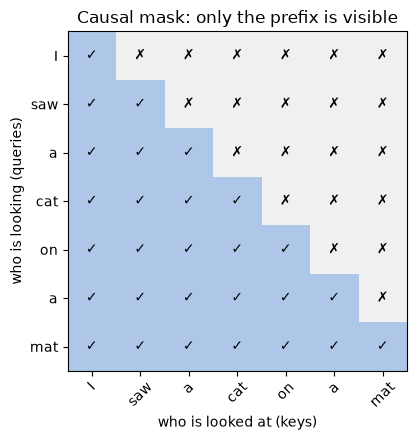

In [10]:
from matplotlib.colors import ListedColormap

tokens = ["I", "saw", "a", "cat", "on", "a", "mat"]
m = causal_mask(len(tokens)).int().numpy()

plt.figure(figsize=(5, 4.5))
plt.imshow(m, cmap=ListedColormap(["#f0f0f0", "#aec7e8"]))
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("who is looked at (keys)")
plt.ylabel("who is looking (queries)")
for i in range(len(tokens)):
    for j in range(len(tokens)):
        plt.text(j, i, "✓" if m[i, j] else "✗", ha="center", va="center")
plt.title("Causal mask: only the prefix is visible")
plt.tight_layout()
plt.show()

A row is the "observer" token, a column is the token it wants to look at. The token "cat" sees itself and everything before it, but not "on", "a" or "mat": at generation time those tokens do not exist yet, and training must proceed under the same conditions.

Let us check that the mask really works: the weights above the diagonal must become zeros.

In [11]:
q, k, v = torch.randn(n, d), torch.randn(n, d), torch.randn(n, d)
_, w_masked = scaled_dot_product_attention(q, k, v, mask=causal_mask(n))

assert np.allclose(np.triu(w_masked.numpy(), k=1), 0.0)          # zeros above the diagonal
assert np.allclose(w_masked.numpy().sum(axis=-1), 1.0, atol=1e-6) # rows are distributions
print("causal mask: ok")

causal mask: ok


**Complexity.** Applying the mask is an elementwise operation on the score table: $O(n^2)$.

## Feed-forward network (FFN)

**Intuition.** Attention is responsible for the *exchange* of information between tokens, but by itself it is an almost linear operation (the only nonlinearity is the softmax over the weights). The FFN is the "digestion" of what was gathered: two linear layers with a nonlinearity in between, applied to each token *independently*. There is no interaction between positions here — all the communication has already happened in attention.

**Formula.**

$$
\mathrm{FFN}(x) = \mathrm{ReLU}(xW_1 + b_1)\,W_2 + b_2,
\qquad W_1 \in \mathbb{R}^{d \times d_{ff}},\; W_2 \in \mathbb{R}^{d_{ff} \times d}.
$$

Note: there is no nonlinearity after the second layer. In the original, $d_{ff} = 4d$ — the network first "expands" the representation fourfold, then compresses it back.

**Code.**

In [12]:
class FeedForward(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.lin1 = nn.Linear(d, d_ff)
        self.lin2 = nn.Linear(d_ff, d)

    def forward(self, x):
        return self.lin2(F.relu(self.lin1(x)))

def feed_forward_np(x, w1, b1, w2, b2):
    return np.maximum(x @ w1 + b1, 0.0) @ w2 + b2

ffn = FeedForward(d, d_ff)
x = torch.randn(n, d)
out_torch = ffn(x)

out_np = feed_forward_np(
    x.numpy(),
    ffn.lin1.weight.detach().numpy().T, ffn.lin1.bias.detach().numpy(),
    ffn.lin2.weight.detach().numpy().T, ffn.lin2.bias.detach().numpy(),
)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-6)
print("FFN: ok", out_torch.shape)

FFN: ok torch.Size([6, 16])


**Complexity.** First layer: $(n \times d) \cdot (d \times d_{ff})$ — $O(n \cdot d \cdot d_{ff})$, plus ReLU $O(n \cdot d_{ff})$. Second layer — again $O(n \cdot d \cdot d_{ff})$. Total $O(n \cdot d \cdot d_{ff})$; at $d_{ff} = 4d$ this is $O(n \cdot d^2)$ with a constant of 8 — in FLOPs the FFN is usually *more expensive* than the attention projections.

## Add & Norm

**Intuition.** These are those "auxiliary mechanisms" from the overview in Part 1 — they do not process information, they help a deep stack of layers train at all. There are two of them, and they are applied around every block (attention or FFN):

- **The residual connection:** the block's output is *added* to its input, $x + \mathrm{Block}(x)$. The block learns not a "new representation from scratch" but a *correction* to the current one; and the gradient gains a short bypass through all the layers — the same short-path logic as with attention, only along the depth.
- **LayerNorm:** each vector is normalized over its own $d$ coordinates — subtract the mean, divide by the standard deviation, then apply a learnable scale $\gamma$ and shift $\beta$. The normalization is per token: for an $n \times d$ input, $n$ independent normalizations are performed; every token has its own mean and variance, and tokens do not interact through LayerNorm in any way. This keeps the scale of activations stable from layer to layer.

**Formula.**

$$
\mathrm{AddNorm}(x) = \mathrm{LayerNorm}(x + \mathrm{Block}(x)), \qquad
\mathrm{LayerNorm}(z) = \gamma \odot \frac{z - \mu(z)}{\sqrt{\sigma^2(z) + \varepsilon}} + \beta.
$$

**Code.**

In [13]:
class AddNorm(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm = nn.LayerNorm(d)

    def forward(self, x, block_out):
        return self.norm(x + block_out)

def add_norm_np(x, block_out, gamma, beta, eps=1e-5):
    z = x + block_out
    mu = z.mean(axis=-1, keepdims=True)
    var = z.var(axis=-1, keepdims=True)
    return gamma * (z - mu) / np.sqrt(var + eps) + beta

add_norm = AddNorm(d)
x, sub = torch.randn(n, d), torch.randn(n, d)
out_torch = add_norm(x, sub)

out_np = add_norm_np(
    x.numpy(), sub.numpy(),
    add_norm.norm.weight.detach().numpy(), add_norm.norm.bias.detach().numpy(),
)

assert np.allclose(out_torch.detach().numpy(), out_np, atol=1e-5)
print("Add & Norm: ok", out_torch.shape)

Add & Norm: ok torch.Size([6, 16])


**Complexity.** Everything is elementwise or a reduction over $d$: $O(n \cdot d)$ — free compared to attention and the FFN.

> 💡 **Pre-LN vs post-LN.** We described the variant from the original paper: normalization *after* the residual sum (post-LN). Modern models more often put the LayerNorm *before* the block (pre-LN): $x + \mathrm{Block}(\mathrm{LayerNorm}(x))$ — deep pre-LN models train noticeably more stably and do not require a careful learning-rate warmup; a systematic comparison of the two variants is in [Xiong et al., 2020](https://arxiv.org/abs/2002.04745). For our toy transformer the difference is not fundamental, and we stay faithful to the original.

> 💡 **Why LayerNorm and not BatchNorm?** First, the difference itself. Take the input tensor $(b, n, d)$: $b$ examples, $n$ positions, $d$ coordinates per token vector. **LayerNorm** averages over a *single* axis — the coordinates: each vector, i.e. the representation of one token, is normalized on its own. That is $b \cdot n$ independent normalizations with $d$ summands in each; tokens do not interact, and the batch plays no role at all. **BatchNorm** averages over the *two remaining* axes at once — examples and positions: for the $j$-th coordinate it computes one shared mean and variance over all $b \cdot n$ tokens of the batch (one statistic per coordinate — not a separate one per example!). That is $d$ normalizations with $b \cdot n$ summands in each, and through them every token depends on its random batch neighbors. Both conventions are easy to verify against [dniku/dl-norms](https://github.com/dniku/dl-norms) — minimal from-scratch implementations of the norm layers, tested to match PyTorch's: BatchNorm averages over "all dims except C", while LayerNorm averages over the trailing `normalized_shape` dims — for the transformer input that is `(d,)`, i.e. all dims *except batch and position*, and it is precisely the "except position" part that makes it per-token.
>
> Now, why is BatchNorm a poor fit here? The dependence on batch neighbors has a well-known cost, not specific to text at all: at inference the batch statistics are replaced by running averages accumulated during training, so the behavior at training and at inference slightly diverges. Computer vision lives with this cost successfully: there the statistics are stable from batch to batch, and the batch noise even helps as regularization. With sequences it is worse. Lengths differ — and although padding is easy to filter out of the statistics, the number of real tokens still jumps from batch to batch; moreover, the activation distributions depend heavily on which tokens landed in the batch — rare words produce outliers. As a result, batch statistics in a transformer are so noisy that the running averages become a poor estimate, and the train/inference mismatch starts to genuinely hurt quality — this is exactly what is shown experimentally in [Shen et al., 2020](https://arxiv.org/abs/2003.07845). Finally, in autoregressive generation the batch may consist of one example and one new token — there is simply nothing to compute statistics from. LayerNorm is free of all this because it is per-token: identical at training and inference, at any sequence length and any batch size.
>
> There is one more variant on the axis menu, sitting between the two: a single normalization over the whole sequence — all $n \cdot d$ numbers of one example. Note that the arguments above do not touch it: it has no batch statistics, hence no running averages and no train/inference mismatch. It fails for reasons of its own. First, its statistics would include future tokens — for the decoder that is an answer leak bypassing the causal mask, and during generation the statistics (and the representations of already-generated tokens) would change with every new token. Second, it does not solve the actual problem: the scale is evened out only *on average over the sentence*, while an individual outlier token with a huge norm remains an outlier — whereas it is precisely individual vectors that saturate the softmax in attention. Per-token normalization fixes each vector individually and opens no extra channels of interaction between tokens.

## Recap: all the blocks and their complexity

All the building blocks are ready and checked against the reference. A complexity summary:

| Block | Complexity | Parameters |
|---|---|---|
| Embeddings | $O(n \cdot d)$ (lookup) | $\lvert V \rvert \cdot d$ |
| Positional encoding | $O(n \cdot d)$ | — |
| Multi-head attention | $O(n^2 \cdot d + n \cdot d^2)$ | $4d^2$ |
| Masks | $O(n^2)$ | — |
| FFN | $O(n \cdot d \cdot d_{ff})$ | $2 d \cdot d_{ff} + d_{ff} + d$ |
| Add & Norm | $O(n \cdot d)$ | $2d$ |

In the next part we will assemble an encoder layer and a decoder layer out of these blocks, stack them into a full model, train it, and count what it all costs — in FLOPs and, no less importantly, in memory.